# Static (Clean)
Author: Yunsik Kim

## Notebook Flow
1. 환경 설정 및 데이터 로드
2. 서비스권역(Voronoi) 생성
3. 2025년 전체 이용량 집계
4. 연평균 시간대 패턴(요일 x 시간)
5. 정류소별 연평균 유입/유출
6. 주중 vs 주말 비교


## 1. 환경 설정 및 데이터 로드


In [1]:
import os
import glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import mapclassify
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram

BASE_DIR = Path('.')
INPUT_DIR = BASE_DIR / 'input'
TRIP_DIR = INPUT_DIR / 'trip_parquet'

print('Working directory:', Path.cwd())


Working directory: /Users/yunsik/Library/CloudStorage/OneDrive-Personal/Charlotte/Coursework/04-Spring2026/GEOG8005/GeoViz_Live/Project


In [2]:
station = pd.read_csv(INPUT_DIR / 'Station.csv', encoding='euc-kr')
seoul = gpd.read_file(INPUT_DIR / 'bnd/seoul.shp')

station.columns = ['stationID', 'address1', 'address2', 'lat', 'long']
station = station[['stationID', 'lat', 'long']]
station = station[(station['lat'] != 0) & (station['long'] != 0)].copy()

station_gdf = gpd.GeoDataFrame(
    station,
    geometry=gpd.points_from_xy(station['long'], station['lat']),
    crs='EPSG:4326'
).to_crs(epsg=5179)

station_gdf = gpd.clip(station_gdf, seoul)
files = sorted(glob.glob(str(TRIP_DIR / 'trip_2025-*.parquet')))

print('Stations in Seoul:', len(station_gdf))
print('Trip parquet files:', len(files))


Stations in Seoul: 3329
Trip parquet files: 365


## 2. 서비스권역(Voronoi) 생성


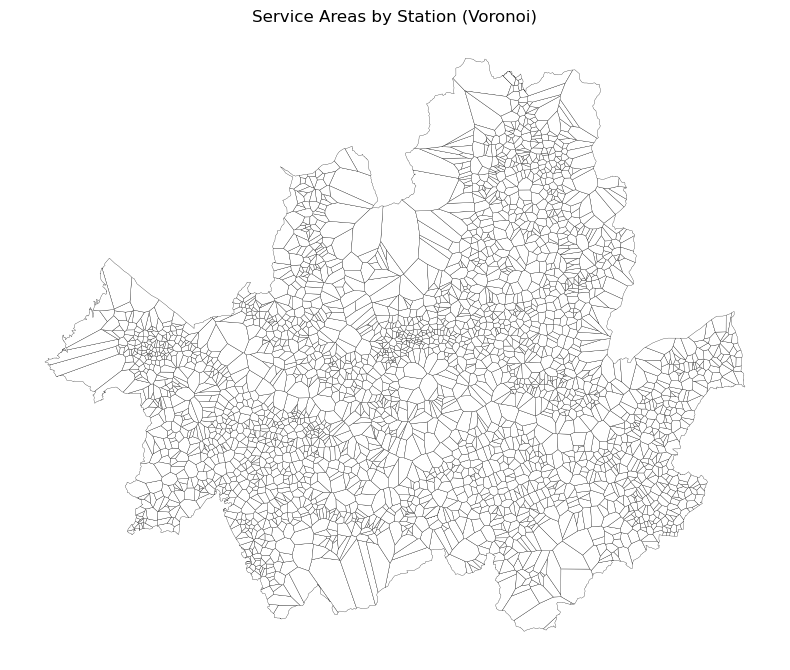

In [3]:
points = MultiPoint(station_gdf.geometry.tolist())
vor = voronoi_diagram(points)

station_vor = gpd.GeoDataFrame(geometry=list(vor.geoms), crs=station_gdf.crs)
station_vor = gpd.sjoin(
    station_vor,
    station_gdf[['stationID', 'geometry']],
    how='left',
    predicate='contains'
)

station_vor_clip = gpd.clip(station_vor, seoul)

fig, ax = plt.subplots(figsize=(8, 8))
station_vor_clip.plot(ax=ax, edgecolor='black', linewidth=0.2, facecolor='white')
ax.set_title('Service Areas by Station (Voronoi)')
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 3. 2025년 전체 이용량 집계


In [4]:
def read_and_filter_trip(parquet_file):
    table = pq.read_table(parquet_file)
    df = table.to_pandas(types_mapper=None)
    return df[(df['USE_DST'] > 200) & (df['USE_MIN'] > 0)].copy()


total_filtered = 0
for f in files:
    total_filtered += len(read_and_filter_trip(f))

print('Total filtered trips in 2025:', total_filtered)


Total filtered trips in 2025: 36298179


## 4. 연평균 시간대 패턴(요일 x 시간)


In [5]:
agg = np.zeros((7, 24), dtype=np.float64)
weekday_file_count = np.zeros(7, dtype=int)

for f in files:
    df = read_and_filter_trip(f)
    df['weekday'] = df['RENT_DT'].dt.weekday
    df['hour'] = df['RENT_DT'].dt.hour

    wd = int(df['weekday'].iloc[0])
    weekday_file_count[wd] += 1

    counts = df.groupby(['weekday', 'hour']).size()
    for (w, h), val in counts.items():
        agg[w, h] += val

avg_agg = np.zeros_like(agg)
for w in range(7):
    if weekday_file_count[w] > 0:
        avg_agg[w, :] = agg[w, :] / weekday_file_count[w]

hourly_avg = pd.DataFrame(
    avg_agg,
    index=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    columns=range(24)
)

hourly_avg


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Mon,1598.307692,986.884615,668.634615,519.673077,528.826923,1248.519231,2842.096154,6876.153846,9685.653846,4687.961538,...,3912.653846,4597.480769,5713.211538,8726.442308,11578.519231,7211.923077,5843.211538,5136.403846,4109.788462,2374.250000
Tue,1682.807692,1189.576923,798.750000,595.173077,578.346154,1289.634615,2856.000000,6863.307692,10049.423077,4915.038462,...,3918.211538,4415.269231,6182.980769,9127.461538,11763.173077,7508.980769,6117.980769,5528.903846,4488.884615,2621.250000
Wed,1905.056604,1337.226415,874.226415,643.886792,601.150943,1330.471698,3023.547170,7295.490566,10340.509434,4950.735849,...,4019.075472,4631.056604,5854.094340,8829.037736,11308.924528,7108.735849,5860.018868,5370.150943,4408.830189,2644.283019
Thu,1927.942308,1341.884615,863.653846,630.730769,579.365385,1236.365385,2767.826923,6732.730769,9873.019231,4892.596154,...,4263.846154,4871.307692,6611.769231,9476.846154,12062.961538,7768.326923,6364.923077,5742.557692,4751.730769,2876.000000
Fri,2103.730769,1472.250000,982.942308,709.750000,619.500000,1233.173077,2686.557692,6453.788462,9245.442308,4665.192308,...,4407.269231,5122.884615,6130.403846,8418.750000,9830.730769,6225.576923,4942.442308,4397.769231,3956.730769,2620.153846
Sat,2090.980769,1617.788462,1083.980769,780.326923,579.153846,699.615385,1033.000000,1688.750000,2800.750000,3484.423077,...,5158.807692,5448.307692,5796.250000,5739.480769,5335.884615,4657.461538,4405.826923,4271.019231,3607.365385,2617.057692
Sun,2260.076923,1621.230769,1140.307692,795.769231,555.576923,620.980769,954.750000,1495.423077,2387.038462,3113.846154,...,5578.153846,6041.980769,6439.769231,6550.807692,6101.423077,5344.461538,4811.192308,4303.634615,3218.788462,2107.807692


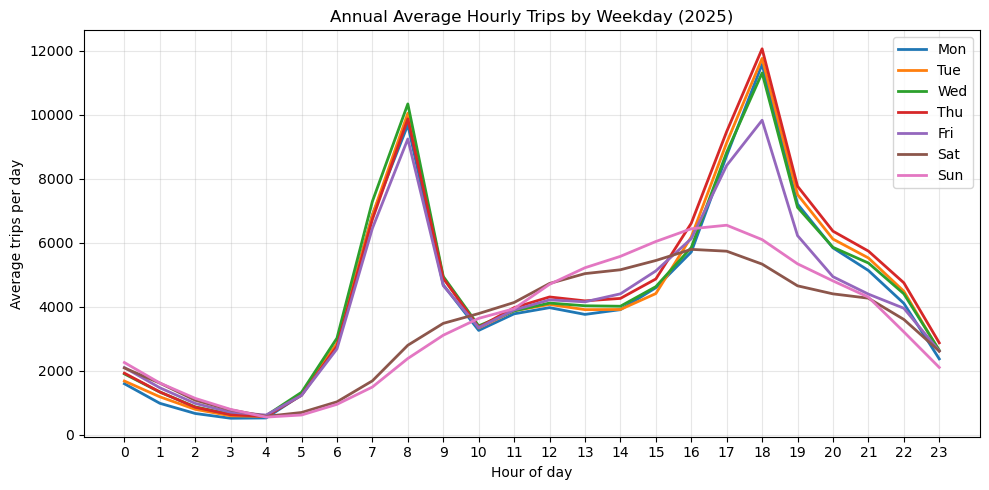

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for wd in range(7):
    ax.plot(
        range(24),
        hourly_avg.iloc[wd],
        label=hourly_avg.index[wd],
        linewidth=2
    )

ax.set_xlabel('Hour of day')
ax.set_ylabel('Average trips per day')
ax.set_xticks(range(24))
ax.set_title('Annual Average Hourly Trips by Weekday (2025)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## 5. 정류소별 연평균 유입/유출


In [7]:
inflow_sum = defaultdict(int)
outflow_sum = defaultdict(int)

for f in files:
    df = read_and_filter_trip(f)

    for sid, val in df.groupby('RETURN_STATION_ID').size().items():
        inflow_sum[sid] += val

    for sid, val in df.groupby('RENT_STATION_ID').size().items():
        outflow_sum[sid] += val

n_days = len(files)
avg_inflow = {k: v / n_days for k, v in inflow_sum.items()}
avg_outflow = {k: v / n_days for k, v in outflow_sum.items()}

station_flow_avg = pd.DataFrame({'stationID': list(set(avg_inflow) | set(avg_outflow))})
station_flow_avg['avg_inflow'] = station_flow_avg['stationID'].map(avg_inflow).fillna(0)
station_flow_avg['avg_outflow'] = station_flow_avg['stationID'].map(avg_outflow).fillna(0)

station_area = station_vor_clip.merge(station_flow_avg, on='stationID', how='left').fillna(0)
station_area[['stationID', 'avg_inflow', 'avg_outflow']].head()


,stationID,avg_inflow,avg_outflow
0,ST-1932,4.846575,4.717808
1,ST-1648,8.284932,7.134247
2,ST-1956,2.041096,2.454795
3,ST-1955,10.043836,10.808219
4,ST-3067,15.060274,14.931507


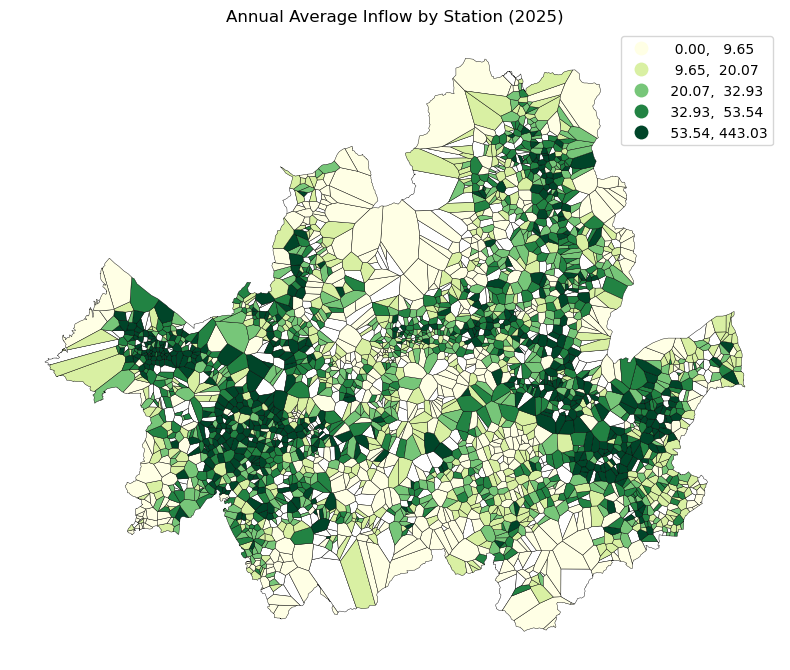

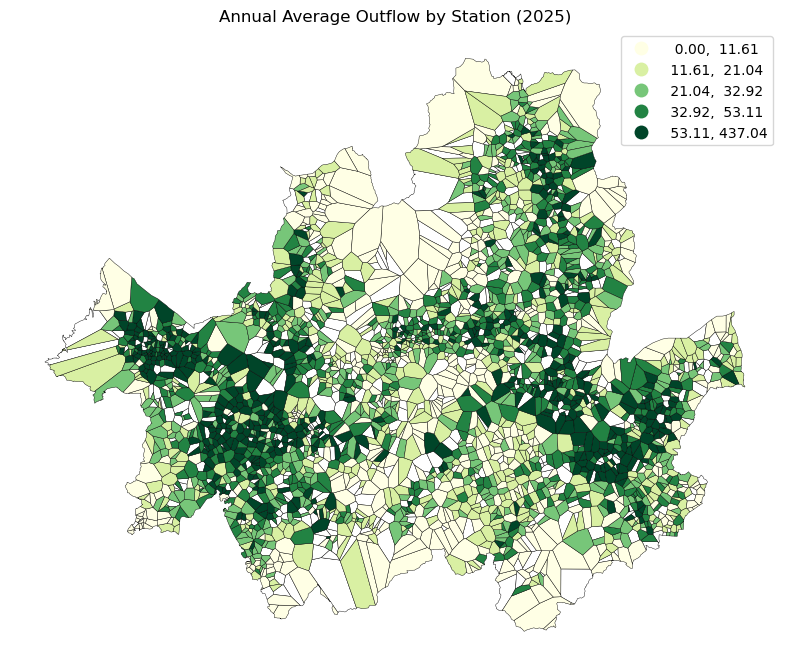

In [8]:
def plot_zero_quantile_map(gdf, column, title, k=5):
    zero_data = gdf[gdf[column] == 0]
    nonzero_data = gdf[gdf[column] > 0].copy()

    fig, ax = plt.subplots(figsize=(8, 8))
    zero_data.plot(ax=ax, color='white', edgecolor='black', linewidth=0.3)

    if not nonzero_data.empty:
        classes = max(1, min(k, nonzero_data[column].nunique()))
        nonzero_data.plot(
            column=column,
            scheme='Quantiles',
            k=classes,
            cmap='YlGn',
            legend=True,
            ax=ax,
            edgecolor='black',
            linewidth=0.3
        )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_zero_quantile_map(station_area, 'avg_inflow', 'Annual Average Inflow by Station (2025)')
plot_zero_quantile_map(station_area, 'avg_outflow', 'Annual Average Outflow by Station (2025)')


## 6. 주중 vs 주말 비교


In [9]:
wd_inflow = defaultdict(int)
wd_outflow = defaultdict(int)
we_inflow = defaultdict(int)
we_outflow = defaultdict(int)

weekday_days = 0
weekend_days = 0

for f in files:
    df = read_and_filter_trip(f)
    day_type = int(df['RENT_DT'].dt.weekday.iloc[0])

    if day_type < 5:
        weekday_days += 1
        for sid, val in df.groupby('RETURN_STATION_ID').size().items():
            wd_inflow[sid] += val
        for sid, val in df.groupby('RENT_STATION_ID').size().items():
            wd_outflow[sid] += val
    else:
        weekend_days += 1
        for sid, val in df.groupby('RETURN_STATION_ID').size().items():
            we_inflow[sid] += val
        for sid, val in df.groupby('RENT_STATION_ID').size().items():
            we_outflow[sid] += val

station_ids = sorted(set(wd_inflow) | set(we_inflow) | set(wd_outflow) | set(we_outflow))
station_week = pd.DataFrame({'stationID': station_ids})

station_week['wd_avg_inflow'] = station_week['stationID'].map(lambda x: wd_inflow[x] / weekday_days if weekday_days else 0)
station_week['wd_avg_outflow'] = station_week['stationID'].map(lambda x: wd_outflow[x] / weekday_days if weekday_days else 0)
station_week['we_avg_inflow'] = station_week['stationID'].map(lambda x: we_inflow[x] / weekend_days if weekend_days else 0)
station_week['we_avg_outflow'] = station_week['stationID'].map(lambda x: we_outflow[x] / weekend_days if weekend_days else 0)

station_week['diff_inflow'] = station_week['we_avg_inflow'] - station_week['wd_avg_inflow']
station_week['diff_outflow'] = station_week['we_avg_outflow'] - station_week['wd_avg_outflow']

station_week_area = station_vor_clip.merge(station_week, on='stationID', how='left').fillna(0)
station_week_area[['stationID', 'diff_inflow', 'diff_outflow']].head()


,stationID,diff_inflow,diff_outflow
0,ST-1932,-1.197355,-0.250810
1,ST-1648,-0.304340,0.377026
2,ST-1956,0.332486,-0.165377
3,ST-1955,-2.777557,-2.515289
4,ST-3067,-7.627947,-7.918509


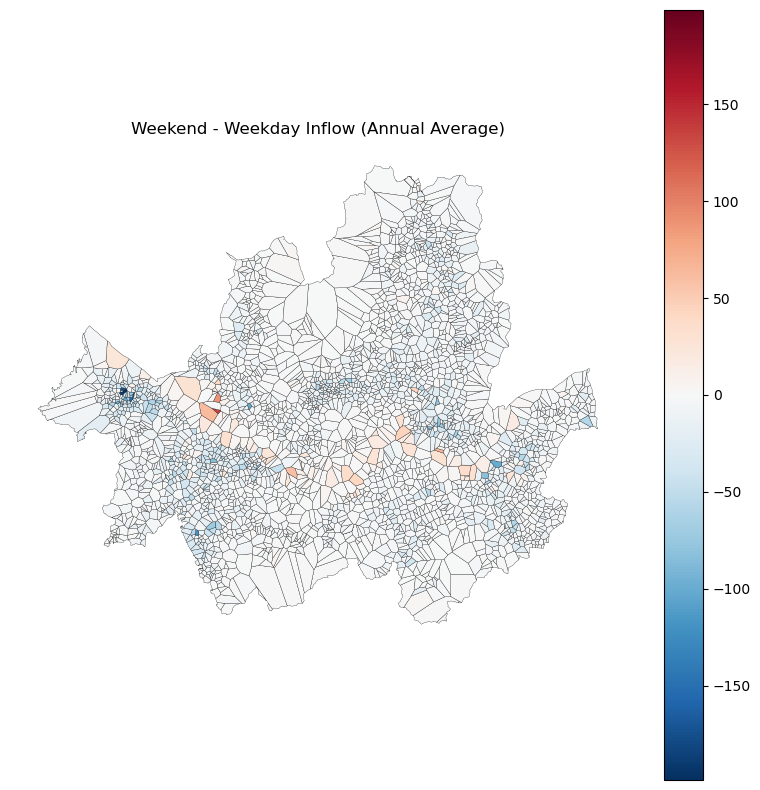

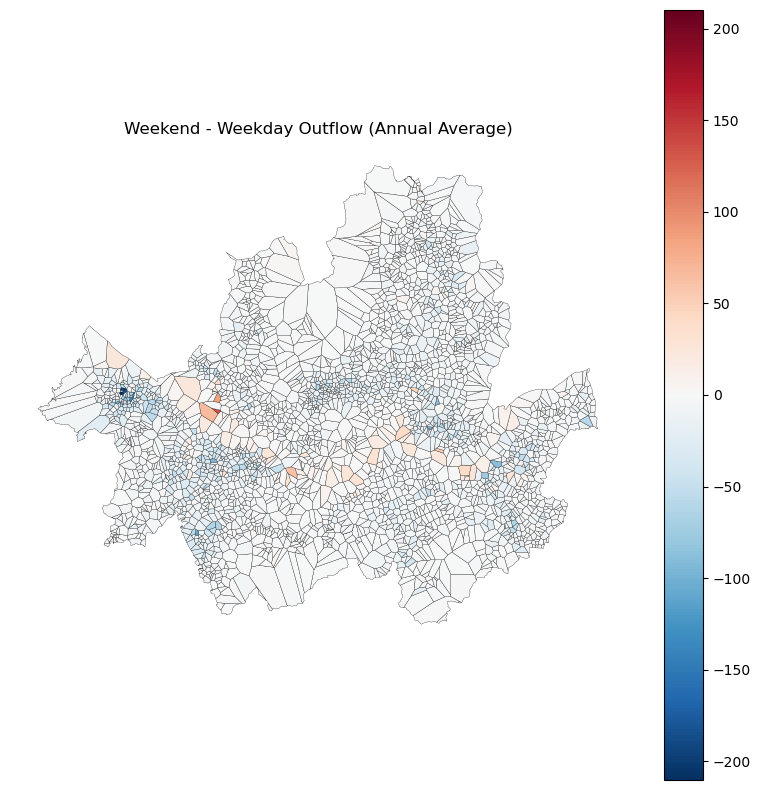

In [10]:
def plot_diff_map(gdf, column, title):
    vmax = np.nanmax(np.abs(gdf[column]))
    fig, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(
        column=column,
        cmap='RdBu_r',
        vmin=-vmax,
        vmax=vmax,
        legend=True,
        edgecolor='black',
        linewidth=0.2,
        ax=ax
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_diff_map(station_week_area, 'diff_inflow', 'Weekend - Weekday Inflow (Annual Average)')
plot_diff_map(station_week_area, 'diff_outflow', 'Weekend - Weekday Outflow (Annual Average)')
